In [3]:
import rioxarray as rxr
import os
from matplotlib.pyplot import imshow
#rom pyproj.proj import proj_coordoperation_is_instantiable
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt
import shutil


In [58]:
#file paths
QSI_path = "SNEX20_QSI_VH_0.5M_USIDMC_20210315_20210315.tif"
GEDI_path = "Raw/Forest_height_2019_NAM.tif"

QSI = rxr.open_rasterio(QSI_path, masked=True).squeeze()
GEDI = rxr.open_rasterio(GEDI_path, masked=True).squeeze()

print(f'QSI CRS {QSI.rio.crs}')
print(f'GEDI CRS {GEDI.rio.crs}')


QSI CRS PROJCS["unnamed",GEOGCS["Unknown datum based upon the GRS 1980 ellipsoid",DATUM["Not_specified_based_on_GRS_1980_ellipsoid",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6019"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4019"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
GEDI CRS EPSG:4326


In [59]:
QSI = QSI.rio.write_crs("EPSG:26911", inplace=False)


In [61]:
QSI_proj = QSI.rio.reproject(GEDI.rio.crs)
print(QSI_proj.rio.crs)
print(GEDI.rio.crs)


EPSG:4326
EPSG:4326


In [62]:
minx, miny, maxx, maxy = QSI_proj.rio.bounds()
print(minx, miny, maxx, maxy)

-115.73613931299539 43.89832335533891 -115.62192071414964 43.99413236151981


In [63]:
GEDI_crop = GEDI.rio.clip_box(
    minx=minx,
    miny=miny,
    maxx=maxx,
    maxy=maxy
)

In [64]:
print(GEDI_crop.rio.bounds())
print(QSI_proj.rio.bounds())

(-115.73624999999998, 43.898250000000004, -115.62174999999999, 43.99425)
(-115.73613931299539, 43.89832335533891, -115.62192071414964, 43.99413236151981)


In [65]:
print(GEDI.rio.resolution())
print(GEDI_crop.rio.resolution())
print(QSI_proj.rio.resolution())

(0.00025, -0.00025)
(0.00024999999999999654, -0.0002500000000000064)
(5.274954918290064e-06, -5.274954918290064e-06)


In [66]:
QSI_resample = QSI_proj.rio.reproject(QSI_proj.rio.crs,resolution = GEDI_crop.rio.resolution())
print(GEDI_crop.rio.resolution())
print(QSI_resample.rio.resolution())

C:\Users\RDCRLSMC\AppData\Local\miniconda3\envs\iceroad\lib\site-packages\rioxarray\raster_writer.py:132: UserWarning: The nodata value (3.402823466e+38) has been automatically changed to (3.4028234663852886e+38) to match the dtype of the data.
  warnings.warn(


(0.00024999999999999654, -0.0002500000000000064)
(0.00024999999999999654, -0.0002500000000000064)


In [67]:
GEDI_resample = GEDI_crop.rio.reproject_match(QSI_resample, resampling=Resampling.bilinear)

C:\Users\RDCRLSMC\AppData\Local\miniconda3\envs\iceroad\lib\site-packages\matplotlib\image.py:513: RuntimeWarning: overflow encountered in multiply
  A_resampled *= ((a_max - a_min) / frac)


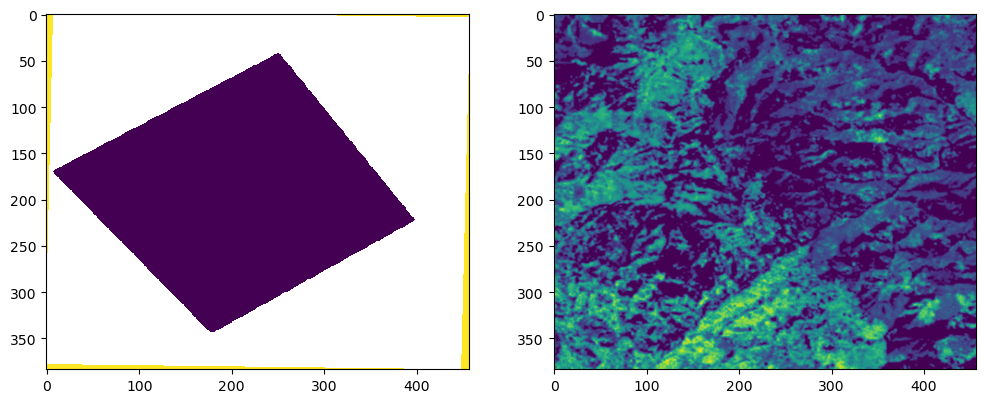

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
axes[0].imshow(QSI_resample)
axes[1].imshow(GEDI_resample)


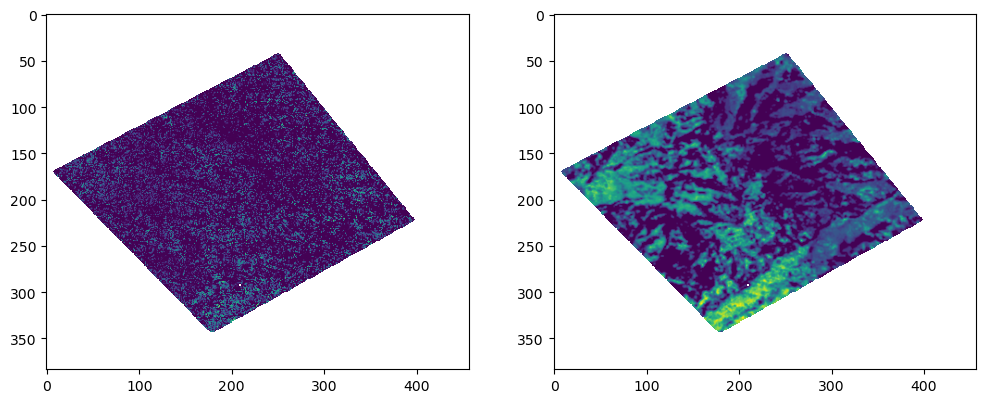

In [69]:
##Mask GEDI by QSI no data values
GEDI_mask = GEDI_resample.where((~np.isnan(QSI_resample)) & (QSI_resample <= 50))
QSI_mask = QSI_resample.where((~np.isnan(QSI_resample)) & (QSI_resample <= 50))

fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
axes[0].imshow(QSI_mask)
axes[1].imshow(GEDI_mask)

In [79]:
# Suppose GEDI_mask is already masked
print("Max:", GEDI_mask.max().item())
print("Min:", GEDI_mask.min().item())

print("Max:", QSI_mask.max().item())
print("Min:", QSI_mask.min().item())

print(GEDI_mask.rio.nodata)
print(QSI_mask.rio.nodata)


Max: 26.154897689819336
Min: 0.0
Max: 45.0111083984375
Min: 0.0
3.4028235e+38
3.4028235e+38


In [96]:
GEDI_int = GEDI_mask.fillna(-9999).astype(np.int32)
GEDI_int.rio.write_nodata(-9999, inplace=True)
QSI_int = QSI_mask.fillna(-9999).astype(np.int32)
QSI_int.rio.write_nodata(-9999, inplace=True)

<xarray.DataArray (y: 384, x: 457)> Size: 702kB
array([[-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       ...,
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999]])
Coordinates:
  * x            (x) float64 4kB -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 3kB 43.99 43.99 43.99 43.99 ... 43.9 43.9 43.9 43.9
    band         int32 4B 1
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        45.983764648438
    STATISTICS_MEAN:           3.5700566911846
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         6.9964307639955
    STATISTICS_VALID_PERCENT:  36.64
    scale_factor:              1.0
    add_offset:                0.0
    _FillValue:                -9999

In [1]:
GEDI_int.rio.to_raster("GEDI_mask_int.tif", dtype="int32")
QSI_int.rio.to_raster("QSI_mask_int.tif", dtype="int32")


NameError: name 'GEDI_int' is not defined

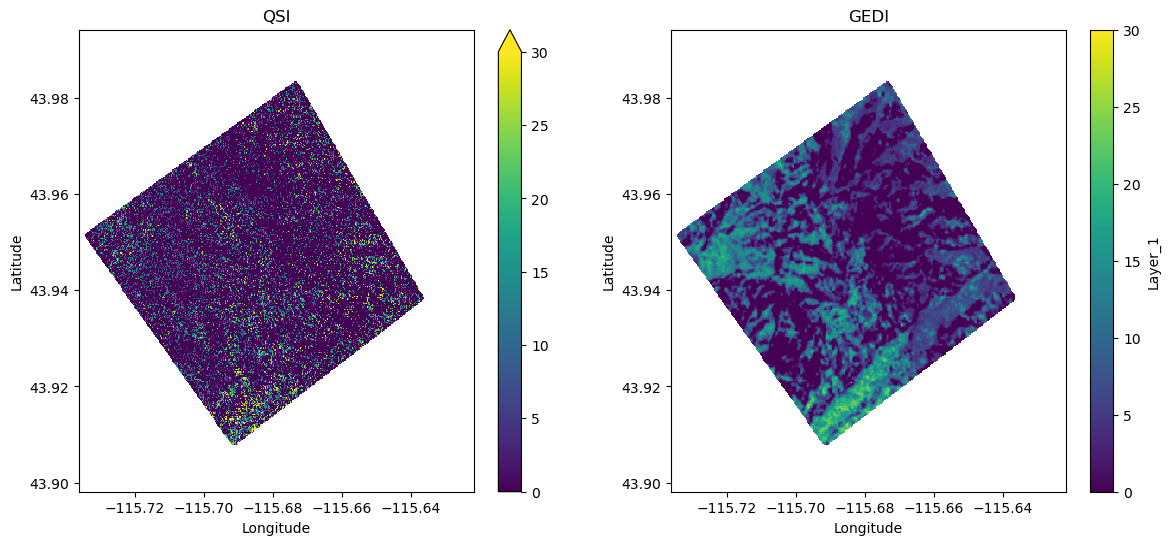

In [4]:
QSI_final = rxr.open_rasterio("QSI_mask_int.tif", masked=True).squeeze()
GEDI_final = rxr.open_rasterio("GEDI_mask_int.tif", masked=True).squeeze()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot QSI
QSI_final.plot(ax=axes[0], cmap='viridis', vmin=0, vmax=30)
axes[0].set_title('QSI')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Plot GEDI
GEDI_final.plot(ax=axes[1], cmap='viridis', vmin=0, vmax=30)
axes[1].set_title('GEDI')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.show()

(array([2.173e+04, 3.274e+03, 3.180e+03, 8.204e+03, 3.931e+03, 3.174e+03,
        4.745e+03, 2.015e+03, 1.877e+03, 1.841e+03, 3.184e+03, 1.570e+03,
        1.032e+03, 1.330e+03, 3.700e+02, 2.830e+02, 3.410e+02, 9.400e+01,
        3.000e+01, 1.000e+01]),
 array([ 0. ,  1.3,  2.6,  3.9,  5.2,  6.5,  7.8,  9.1, 10.4, 11.7, 13. ,
        14.3, 15.6, 16.9, 18.2, 19.5, 20.8, 22.1, 23.4, 24.7, 26. ]),
 <BarContainer object of 20 artists>)

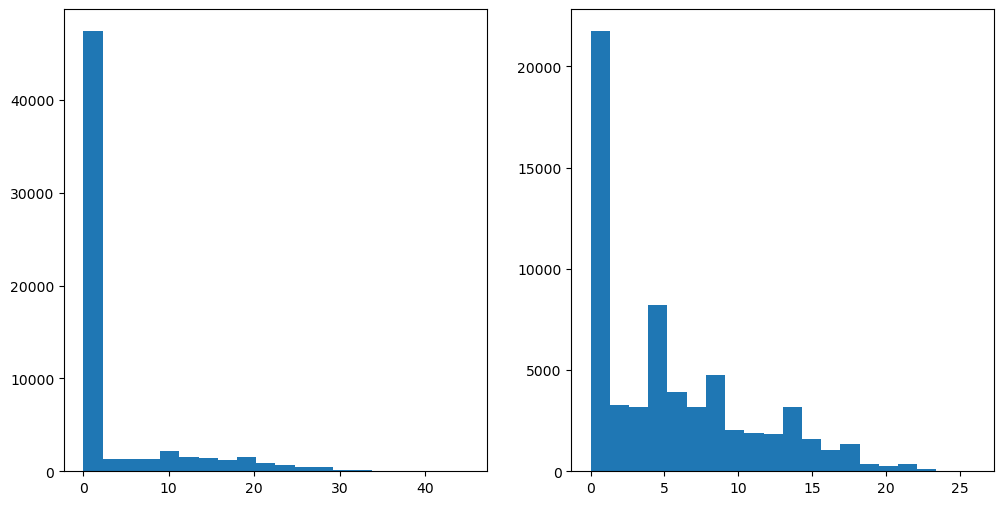

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
axes[0].hist(QSI_final.values.ravel(), bins=20)
axes[1].hist(GEDI_final.values.ravel(), bins=20)